Starting training (defensive version)...
Epoch     1 | Loss=3.061e+02 | PDE=4.182e-02 | BC=1.530e+00
Epoch   200 | Loss=3.442e-01 | PDE=3.434e-01 | BC=4.113e-06
Epoch   400 | Loss=2.100e-01 | PDE=2.097e-01 | BC=1.736e-06
Epoch   600 | Loss=1.443e-01 | PDE=1.441e-01 | BC=9.094e-07
Epoch   800 | Loss=1.240e-01 | PDE=1.239e-01 | BC=4.980e-07
Epoch  1000 | Loss=1.000e-01 | PDE=9.991e-02 | BC=5.116e-07
Epoch  1200 | Loss=8.493e-02 | PDE=8.486e-02 | BC=3.655e-07
Epoch  1400 | Loss=6.845e-02 | PDE=6.840e-02 | BC=2.430e-07
Epoch  1600 | Loss=5.806e-02 | PDE=5.802e-02 | BC=2.093e-07
Epoch  1800 | Loss=4.669e-02 | PDE=4.666e-02 | BC=1.219e-07
Epoch  2000 | Loss=4.094e-02 | PDE=4.093e-02 | BC=8.396e-08
Epoch  2200 | Loss=3.569e-02 | PDE=3.568e-02 | BC=5.833e-08
Epoch  2400 | Loss=2.983e-02 | PDE=2.982e-02 | BC=4.194e-08
Epoch  2600 | Loss=2.635e-02 | PDE=2.635e-02 | BC=1.344e-08
Epoch  2800 | Loss=7.893e-02 | PDE=2.174e-02 | BC=2.860e-04
Epoch  3000 | Loss=1.964e-02 | PDE=1.953e-02 | BC=5.684e-07

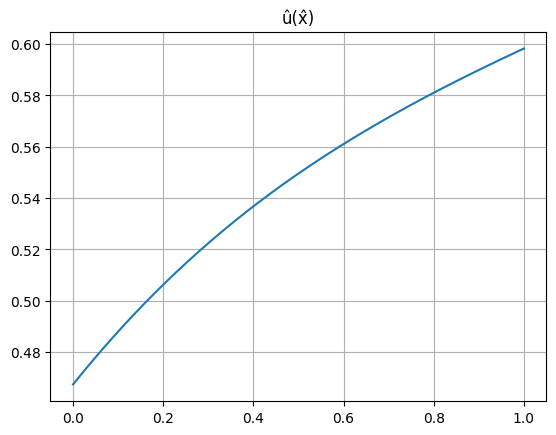

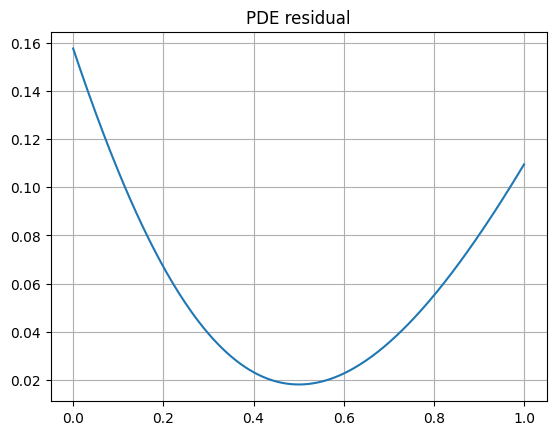

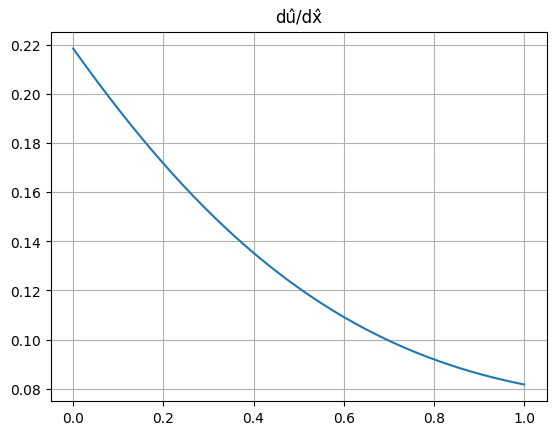

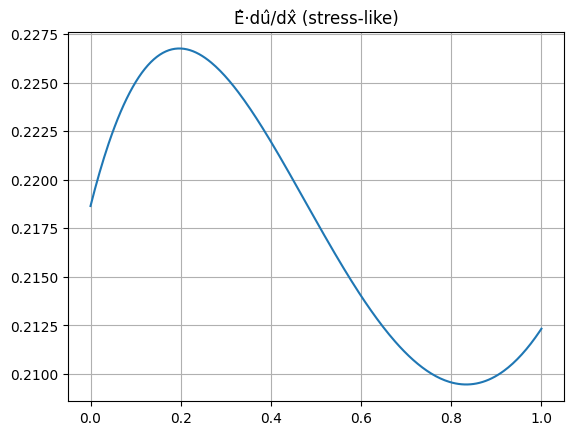

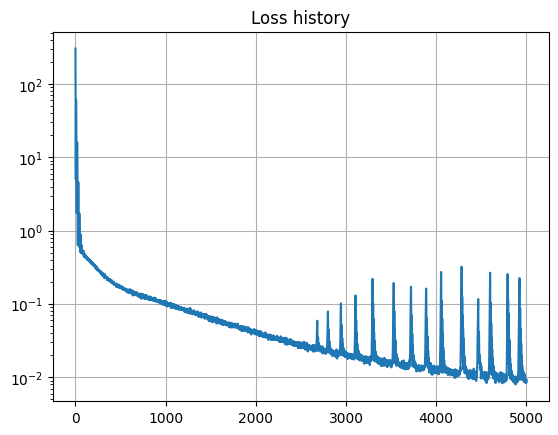

In [ ]:
# defensive_pinn_tf_debug.py
# Fully self-contained TF2 PINN with robust gradient-watching and diagnostics.
# Paste into Colab or run locally after `pip install tensorflow matplotlib numpy`.

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import traceback, sys, os

tf.random.set_seed(1234)
np.random.seed(1234)

# ---------------- problem params ----------------
L = 1.0
E_min_GPa, E_max_GPa = 50.0, 210.0
E_ref_GPa = 50.0
a_min, a_max = -0.8, 0.8
E_span_ratio = E_max_GPa / E_ref_GPa
b_min, b_max = 0.0, E_span_ratio - 1.0
T_hat = 1.0

layers = [3, 64, 64, 64, 1]   # input: (xhat,a,b) -> u_hat
epochs = 5000
n_colloc = 2000
w_pde, w_bc = 1.0, 200.0
lr = 1e-3
out_dir = "pinn_tf_debug_out"
os.makedirs(out_dir, exist_ok=True)

# ---------------- model ----------------
class PINN(tf.keras.Model):
    def __init__(self, layers):
        super().__init__()
        self.hidden = []
        for n in layers[1:-1]:
            self.hidden.append(tf.keras.layers.Dense(n, activation=tf.nn.tanh,
                                                     kernel_initializer='glorot_normal'))
        self.out = tf.keras.layers.Dense(layers[-1], activation=None,
                                         kernel_initializer='glorot_normal')

    def call(self, x):
        z = x
        for layer in self.hidden:
            z = layer(z)
        return self.out(z)

# ---------------- helpers ----------------
def E_hat(xhat, b):
    # expects tensors shape (N,1)
    return 1.0 + b * xhat

def A_hat(xhat, a):
    return 1.0 + a * xhat

# ---------------- PDE residual (defensive) ----------------
def pde_residual(model, xhat_np, params_np):
    """
    xhat_np: numpy array shape (N,1)
    params_np: numpy array shape (N,2) columns [a,b]
    returns: (dflux_dx, u_hat, du_dx) all tf.Tensor with shape (N,1)
    """
    # convert and ensure shapes
    xhat_tf = tf.convert_to_tensor(np.asarray(xhat_np, dtype=np.float32))
    params_tf = tf.convert_to_tensor(np.asarray(params_np, dtype=np.float32))
    xhat_tf = tf.reshape(xhat_tf, (-1, 1))
    params_tf = tf.reshape(params_tf, (-1, 2))

    # nested tapes; explicitly watch xhat so gradient is tracked
    with tf.GradientTape(persistent=True) as tape_outer:
        tape_outer.watch(xhat_tf)
        with tf.GradientTape() as tape_inner:
            tape_inner.watch(xhat_tf)
            inp = tf.concat([xhat_tf, params_tf], axis=1)   # (N,3)
            u_hat = model(inp)                              # (N,1)
        du_dx = tape_inner.gradient(u_hat, xhat_tf)         # may be None if not watched
        # defensive check
        if du_dx is None:
            # print diagnostics and raise readable error
            print("ERROR: du_dx is None. Diagnostics follow:")
            print(" xhat_tf dtype/shape:", xhat_tf.dtype, xhat_tf.shape)
            print(" params_tf dtype/shape:", params_tf.dtype, params_tf.shape)
            print(" model output dtype/shape:", u_hat.dtype, u_hat.shape)
            # try a tiny forward pass to display weights existence
            try:
                sample_inp = tf.concat([xhat_tf[:1,:], params_tf[:1,:]], axis=1)
                sample_out = model(sample_inp)
                print("sample_out:", sample_out.numpy())
            except Exception as e:
                print("Error evaluating sample forward:", e)
            raise RuntimeError("du_dx is None: TensorFlow could not compute gradient w.r.t. xhat. "
                               "Ensure xhat is watched (we attempted to watch it). See diagnostics above.")

        a = params_tf[:, 0:1]
        b = params_tf[:, 1:2]
        Ehat = E_hat(xhat_tf, b)
        Ahat = A_hat(xhat_tf, a)
        flux = Ehat * Ahat * du_dx

    dflux_dx = tape_outer.gradient(flux, xhat_tf)
    # final defensive check
    if dflux_dx is None:
        print("WARNING: dflux_dx is None (second derivative failed). Shapes:")
        print(" flux shape:", flux.shape)
        raise RuntimeError("dflux_dx is None: failed to compute derivative of flux w.r.t xhat.")
    del tape_outer
    return dflux_dx, u_hat, du_dx

# ---------------- loss components ----------------
mse = tf.keras.losses.MeanSquaredError()

def loss_pde(model, x_colloc_np, params_colloc_np):
    res, _, _ = pde_residual(model, x_colloc_np, params_colloc_np)
    return tf.reduce_mean(tf.square(res))

def loss_bc(model, bc_dict):
    loss = tf.constant(0.0, dtype=tf.float32)
    if 'dirichlet' in bc_dict:
        for x_val, params, u_val in bc_dict['dirichlet']:
            xi = tf.constant([[float(x_val)]], dtype=tf.float32)
            pi = tf.constant([[float(params[0]), float(params[1])]], dtype=tf.float32)
            ui = model(tf.concat([xi, pi], axis=1))
            loss += mse(tf.constant([[float(u_val)]], dtype=tf.float32), ui)
    if 'neumann' in bc_dict:
        for x_val, params, t_val in bc_dict['neumann']:
            x_var = tf.Variable([[float(x_val)]], dtype=tf.float32)
            p_tf = tf.constant([[float(params[0]), float(params[1])]], dtype=tf.float32)
            with tf.GradientTape() as tape:
                tape.watch(x_var)
                ui = model(tf.concat([x_var, p_tf], axis=1))
            dui = tape.gradient(ui, x_var)
            a = p_tf[:,0:1]; b = p_tf[:,1:2]
            traction = E_hat(x_var, b) * A_hat(x_var, a) * dui
            loss += mse(tf.constant([[float(t_val)]], dtype=tf.float32), traction)
    return loss

# ---------------- training (with diagnostics) ----------------
def train(model, epochs=1000, n_colloc=1000, lr=1e-3, w_pde=1.0, w_bc=200.0, print_every=200):
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    mid_a = float(0.0); mid_b = float(0.5*(b_min+b_max))
    bc = {
        'dirichlet': [(0.0, (mid_a, mid_b), 0.0)],
        'neumann':   [(1.0, (mid_a, mid_b), T_hat)]
    }
    hist = []
    for ep in range(1, epochs+1):
        try:
            # create numpy collocation samples (we convert inside pde_residual)
            x_colloc = np.random.rand(n_colloc,1).astype(np.float32)
            a_samps = np.random.uniform(a_min, a_max, (n_colloc,1)).astype(np.float32)
            b_samps = np.random.uniform(b_min, b_max, (n_colloc,1)).astype(np.float32)
            params_colloc = np.concatenate([a_samps, b_samps], axis=1)

            with tf.GradientTape() as tape:
                Lpde = loss_pde(model, x_colloc, params_colloc)
                Lbc = loss_bc(model, bc)
                loss = w_pde * Lpde + w_bc * Lbc

            grads = tape.gradient(loss, model.trainable_variables)
            # defensive: check grads for None
            if any(g is None for g in grads):
                print("WARNING: some grads are None. Debugging grads list:")
                for i,g in enumerate(grads):
                    print(i, type(g), None if g is None else g.shape)
                raise RuntimeError("None gradient encountered in optimizer step. See printed grads info.")

            opt.apply_gradients(zip(grads, model.trainable_variables))
            hist.append(float(loss.numpy()))
            if ep % print_every == 0 or ep==1:
                print(f"Epoch {ep:5d} | Loss={loss.numpy():.3e} | PDE={Lpde.numpy():.3e} | BC={Lbc.numpy():.3e}")
        except Exception as e:
            # print full traceback and re-raise so user can paste it
            print("Exception during training at epoch", ep)
            traceback.print_exc()
            raise
    return hist

# ---------------- main ----------------
if __name__ == "__main__":
    try:
        model = PINN(layers)
        # Optionally build model (call once) to catch shape issues early
        sample_inp = tf.zeros((1,3), dtype=tf.float32)
        _ = model(sample_inp)

        print("Starting training (defensive version)...")
        hist = train(model, epochs=epochs, n_colloc=n_colloc, lr=lr, w_pde=w_pde, w_bc=w_bc, print_every=200)
        print("Training finished. Final loss:", hist[-1])

        # post-train evaluation & plots (choose example params)
        a_plot, b_plot = 0.3, 0.5*(b_min+b_max)
        x_eval = np.linspace(0,1,300)[:,None].astype(np.float32)
        params_eval = np.concatenate([np.full_like(x_eval, a_plot), np.full_like(x_eval, b_plot)], axis=1)
        res, uhat, du = pde_residual(model, x_eval, params_eval)
        res_np = res.numpy().flatten(); u_np = uhat.numpy().flatten(); du_np = du.numpy().flatten()
        Ehat_np = (1.0 + b_plot * x_eval).flatten()
        stress_like = Ehat_np * du_np

        plt.figure(); plt.plot(x_eval, u_np); plt.title("û(x̂)"); plt.grid(); plt.show()
        plt.figure(); plt.plot(x_eval, res_np); plt.title("PDE residual"); plt.grid(); plt.show()
        plt.figure(); plt.plot(x_eval, du_np); plt.title("dû/dx̂"); plt.grid(); plt.show()
        plt.figure(); plt.plot(x_eval, stress_like); plt.title("Ê·dû/dx̂ (stress-like)"); plt.grid(); plt.show()
        plt.figure(); plt.semilogy(hist); plt.title("Loss history"); plt.grid(); plt.show()

    except Exception as e:
        print("Fatal error in main. Full traceback below:")
        traceback.print_exc()
        # re-raise if you want kernel-level failure:
        # raise
        sys.exit(1)


In [ ]:
# pinn_axial_bar.py
# PyTorch PINN for 1D axial bar with linearly-varying E and A.
# Uses tanh activations and Adam optimizer.
# Adjust BCs, forcing, and normalization to match your PDF specifics.

import torch
import torch.nn as nn
import numpy as np

# ---- CONFIG / PHYSICAL RANGES ----
device = "cuda" if torch.cuda.is_available() else "cpu"

# Physical lengths and refs (user can change)
L = 1.0                # physical length (m) -- choose consistent units with E and A
E_min_GPa, E_max_GPa = 50.0, 210.0
# choose reference E (we will nondim by E_ref)
E_ref_GPa = E_min_GPa   # you can instead use mean or max
A0_mm2 = 100.0          # reference area in mm^2 (user can set)
# Convert units if needed: if using SI, convert mm^2->m^2:
A0 = A0_mm2 * 1e-6

# parameter ranges for linear variation
a_min, a_max = -0.8, 0.8   # for hat A(x) = 1 + a * xhat
# We'll parametrize hat E(x) = 1 + b * xhat where b set so E spans desired range
E_span_ratio = E_max_GPa / E_ref_GPa
# if E_hat(0)=1 and E_hat(1)=E_span_ratio then b = E_span_ratio-1
b_min, b_max = 0.0, E_span_ratio - 1.0

# Reference nondimensionalization: we choose U_ref = L (geometric scale)
U_ref = L

# ---- Neural network ----
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = torch.tanh

        # Xavier init
        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        # x shape: (N, d_in)
        z = x
        for i, layer in enumerate(self.net[:-1]):
            z = layer(z)
            z = self.activation(z)
        z = self.net[-1](z)
        return z

# ---- helpers for E_hat and A_hat ----
def E_hat(xhat, b_param):
    # linear: E_hat = 1 + b * xhat
    return 1.0 + b_param * xhat

def A_hat(xhat, a_param):
    # A_hat = 1 + a * xhat
    return 1.0 + a_param * xhat

# ---- PDE residual function ----
def pde_residual(model, xhat_tensor, params_tensor):
    # params_tensor contains [a_param, b_param] for each sample row
    xhat_tensor = xhat_tensor.requires_grad_(True)
    inp = torch.cat([xhat_tensor, params_tensor], dim=1).to(device)  # shape (N,3) if params used
    u_hat = model(inp)                 # network outputs nondim disp u_hat
    # first derivative du/dxhat
    du = torch.autograd.grad(u_hat, xhat_tensor, torch.ones_like(u_hat), create_graph=True)[0]
    # params:
    a_param = params_tensor[:, [0]]
    b_param = params_tensor[:, [1]]
    Ehat = E_hat(xhat_tensor, b_param)
    Ahat = A_hat(xhat_tensor, a_param)

    # compute flux = Ehat * Ahat * du/dxhat
    flux = Ehat * Ahat * du
    # derivative of flux w.r.t xhat
    dflux_dx = torch.autograd.grad(flux, xhat_tensor, torch.ones_like(flux), create_graph=True)[0]
    # body force term: here zero (steady axial), but user can add nondim fhat(x)
    fhat = torch.zeros_like(dflux_dx)  # placeholder
    res = dflux_dx.squeeze(-1) + fhat.squeeze(-1)
    return res, u_hat

# ---- loss functions ----
mse = nn.MSELoss()

def loss_pde(model, x_colloc, params_colloc):
    res, _ = pde_residual(model, x_colloc, params_colloc)
    return torch.mean(res**2)

def loss_bc(model, bc_dict):
    # bc_dict example:
    # {'dirichlet': [(xhat, params, uhat_target), ...],
    #  'neumann':   [(xhat, params, traction_target), ...] }
    loss = 0.0
    count = 0
    if 'dirichlet' in bc_dict:
        for xhat, params, u_t in bc_dict['dirichlet']:
            xh = torch.tensor([[xhat]], dtype=torch.float32).to(device)
            p = torch.tensor([params], dtype=torch.float32).to(device)
            inp = torch.cat([xh, p], dim=1)
            u_pred = model(inp)
            loss = loss + mse(u_pred, torch.tensor([[u_t]], dtype=torch.float32).to(device))
            count += 1
    if 'neumann' in bc_dict:
        for xhat, params, t_target in bc_dict['neumann']:
            xh = torch.tensor([[xhat]], dtype=torch.float32).requires_grad_(True).to(device)
            p = torch.tensor([params], dtype=torch.float32).to(device)
            inp = torch.cat([xh, p], dim=1)
            u_pred = model(inp)
            du_dx = torch.autograd.grad(u_pred, xh, torch.ones_like(u_pred), create_graph=True)[0]
            a_param = p[:, [0]]
            b_param = p[:, [1]]
            Ehat_val = E_hat(xh, b_param)
            Ahat_val = A_hat(xh, a_param)
            traction = (Ehat_val * Ahat_val * du_dx).squeeze(-1)
            loss = loss + mse(traction, torch.tensor([t_target], dtype=torch.float32).to(device))
            count += 1
    if count==0:
        return torch.tensor(0.0, dtype=torch.float32, device=device)
    return loss

def loss_data(model, data_points):
    # data_points = [(xhat, params, uhat_meas), ...]
    if not data_points:
        return torch.tensor(0.0, dtype=torch.float32, device=device)
    loss = 0.0
    for xhat, params, u_m in data_points:
        xh = torch.tensor([[xhat]], dtype=torch.float32).to(device)
        p = torch.tensor([params], dtype=torch.float32).to(device)
        inp = torch.cat([xh, p], dim=1)
        u_pred = model(inp)
        loss += mse(u_pred, torch.tensor([[u_m]], dtype=torch.float32).to(device))
    return loss / max(1, len(data_points))

# ---- Training function ----
def train_pinn(model, epochs=5000,
               n_colloc=2000,
               bc_dict=None,
               data_points=None,
               w_pde=1.0, w_bc=50.0, w_ic=0.0, w_data=1.0,
               print_every=200):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(1, epochs+1):
        optimizer.zero_grad()
        # sample collocation points xhat in (0,1)
        x_colloc = torch.rand((n_colloc,1), dtype=torch.float32).to(device)
        # sample params uniformly in ranges (a, b). Note: b translates to E variation
        a_sample = (a_max - a_min) * torch.rand((n_colloc,1), dtype=torch.float32) + a_min
        b_sample = (b_max - b_min) * torch.rand((n_colloc,1), dtype=torch.float32) + b_min
        params_colloc = torch.cat([a_sample, b_sample], dim=1).to(device)

        # compute losses
        L_pde = loss_pde(model, x_colloc, params_colloc)
        L_bc = loss_bc(model, bc_dict if bc_dict is not None else {})
        L_data = loss_data(model, data_points if data_points is not None else [])
        L_ic = torch.tensor(0.0, dtype=torch.float32, device=device)  # placeholder

        loss = w_pde * L_pde + w_bc * L_bc + w_ic * L_ic + w_data * L_data

        loss.backward()
        optimizer.step()

        if ep % print_every == 0 or ep==1:
            print(f"Epoch {ep:6d} | Loss {loss.item():.3e} | PDE {L_pde.item():.3e} | BC {L_bc.item():.3e} | data {L_data.item():.3e}")
    return model

# ---- Example usage ----
if __name__ == "__main__":
    # Network accepts input (xhat, a_param, b_param) -> u_hat
    layers = [3, 64, 64, 64, 1]
    model = PINN(layers)

    # Example BCs: Dirichlet u(0)=0, Dirichlet u(1)=0 (simply supported displacement fix)
    # Note: values must be nondimensional u_hat = u/U_ref. Using U_ref=L => u_hat_target = u/L
    bc = {
        'dirichlet': [
            (0.0, (0.0, 0.0), 0.0),    # at xhat=0 with params (a=0,b=0) uhat=0
            (1.0, (0.0, 0.0), 0.0)     # at xhat=1
        ],
        # if you prefer a traction at x=1 use 'neumann' entries instead
        # 'neumann': [(1.0, (a_value, b_value), traction_hat_value), ...]
    }

    # Optional measured data points example (empty here)
    data_pts = []

    trained = train_pinn(model,
                        epochs=3000,
                        n_colloc=2000,
                        bc_dict=bc,
                        data_points=data_pts,
                        w_pde=1.0, w_bc=100.0, w_ic=0.0, w_data=1.0,
                        print_every=250)

    # Example inference at a single (xhat,a,b)
    model.eval()
    x_test = torch.tensor([[0.3]], dtype=torch.float32).to(device)
    params_test = torch.tensor([[0.2, 0.5]], dtype=torch.float32).to(device)
    inp = torch.cat([x_test, params_test], dim=1)
    with torch.no_grad():
        uhat_pred = model(inp)
    print("Predicted u_hat:", uhat_pred.cpu().numpy())


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch      1 | Loss 2.386e-01 | PDE 8.869e-02 | BC 1.499e-03 | data 0.000e+00
Epoch    250 | Loss 1.839e-04 | PDE 1.839e-04 | BC 3.658e-10 | data 0.000e+00
Epoch    500 | Loss 8.552e-05 | PDE 8.551e-05 | BC 1.596e-10 | data 0.000e+00
Epoch    750 | Loss 4.776e-05 | PDE 4.776e-05 | BC 8.878e-13 | data 0.000e+00
Epoch   1000 | Loss 2.422e-05 | PDE 2.422e-05 | BC 6.103e-12 | data 0.000e+00
Epoch   1250 | Loss 1.228e-05 | PDE 1.228e-05 | BC 1.372e-11 | data 0.000e+00
Epoch   1500 | Loss 7.240e-06 | PDE 7.237e-06 | BC 3.764e-11 | data 0.000e+00
Epoch   1750 | Loss 4.845e-06 | PDE 4.831e-06 | BC 1.362e-10 | data 0.000e+00
Epoch   2000 | Loss 1.208e-05 | PDE 5.245e-06 | BC 6.838e-08 | data 0.000e+00
Epoch   2250 | Loss 7.183e-04 | PDE 1.250e-05 | BC 7.058e-06 | data 0.000e+00
Epoch   2500 | Loss 2.568e-06 | PDE 2.542e-06 | BC 2.597e-10 | data 0.000e+00
Epoch   2750 | Loss 2.074e-06 | PDE 2.073e-06 | BC 4.274e-12 | data 0.000e+00
Epoch   3000 | Loss 2.178e-06 | PDE 2.136e-06 | BC 4.239e-10 | d

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     1 | Loss=8.761e+01 | PDE=1.571e-01 | BC=4.373e-01
Epoch   300 | Loss=1.916e-01 | PDE=1.913e-01 | BC=1.464e-06
Epoch   600 | Loss=1.122e-01 | PDE=1.121e-01 | BC=4.492e-07
Epoch   900 | Loss=6.662e-02 | PDE=6.654e-02 | BC=3.929e-07
Epoch  1200 | Loss=4.092e-02 | PDE=4.088e-02 | BC=1.682e-07
Epoch  1500 | Loss=1.946e-01 | PDE=2.832e-02 | BC=8.314e-04
Epoch  1800 | Loss=2.382e-02 | PDE=2.382e-02 | BC=3.094e-08
Epoch  2100 | Loss=5.635e-02 | PDE=2.218e-02 | BC=1.709e-04
Epoch  2400 | Loss=1.653e-02 | PDE=1.653e-02 | BC=8.254e-10
Epoch  2700 | Loss=1.580e-02 | PDE=1.580e-02 | BC=1.994e-09
Epoch  3000 | Loss=1.072e-01 | PDE=1.301e-02 | BC=4.708e-04
Epoch  3300 | Loss=1.278e-02 | PDE=1.278e-02 | BC=3.028e-09
Epoch  3600 | Loss=1.019e-02 | PDE=1.019e-02 | BC=1.346e-08
Epoch  3900 | Loss=6.027e-02 | PDE=8.791e-03 | BC=2.574e-04
Epoch  4200 | Loss=8.503e-03 | PDE=8.502e-03 | BC=5.289e-09
Epoch  4500 | Loss=4.565e-02 | PDE=9.524e-03 | BC=1.806e-04
Epoch  4800 | Loss=7.708e-03 | PDE=7.705

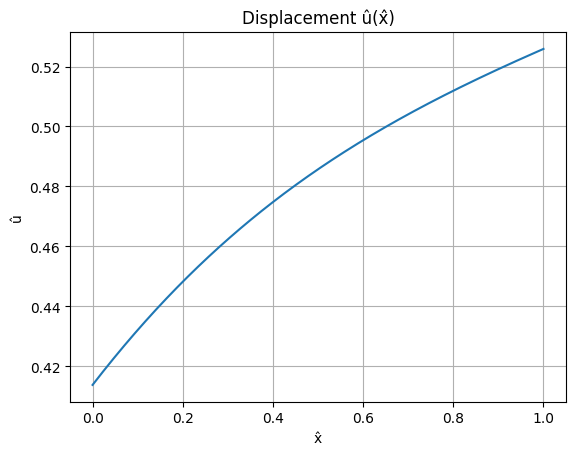

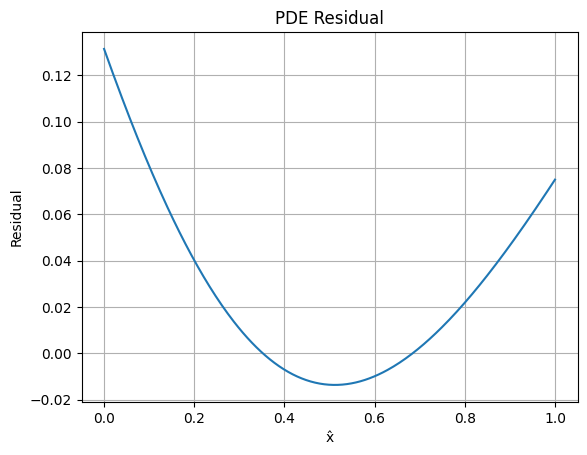

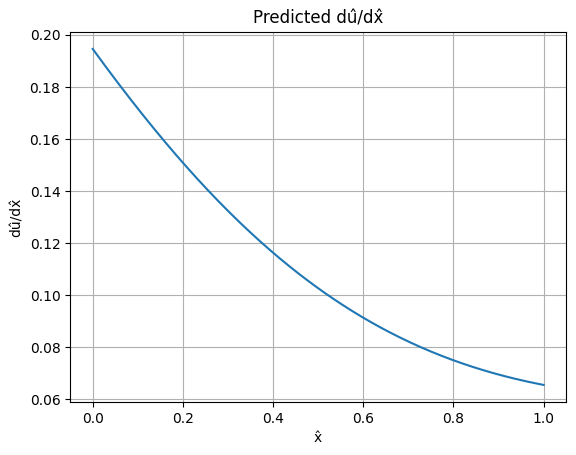

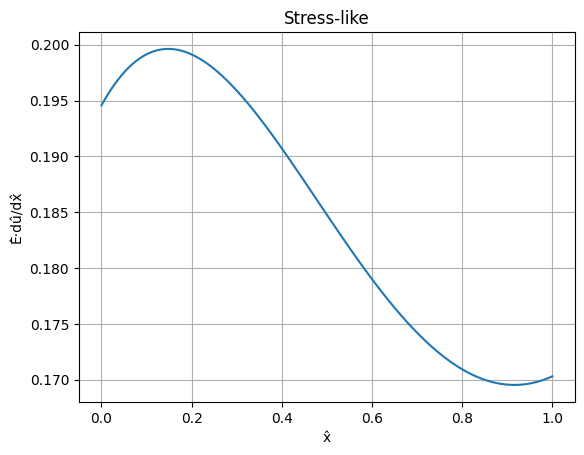

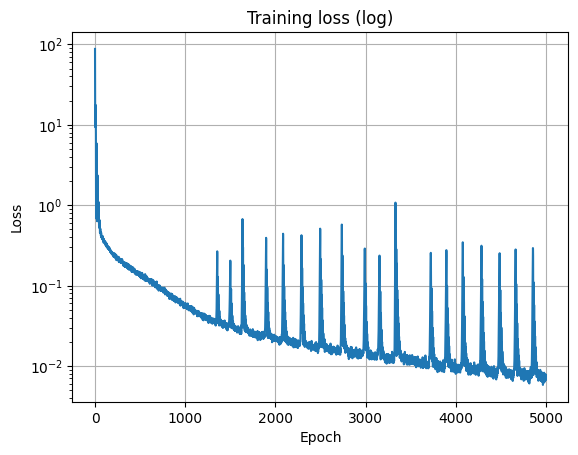

In [ ]:
# pinn_axial_bar_plots.py
# PyTorch PINN for 1D cantilever bar with variable E(x) and A(x)
# Includes tanh activation, Adam optimizer, PDE+BC losses, and plotting

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------- Physical ranges ----------------------
L = 1.0                     # nondimensional length
E_min_GPa, E_max_GPa = 50.0, 210.0
E_ref_GPa = 50.0            # reference for nondim Ê
A0_mm2 = 100.0
A0 = A0_mm2 * 1e-6          # convert mm^2→m^2 (for clarity)
a_min, a_max = -0.8, 0.8
E_span_ratio = E_max_GPa / E_ref_GPa
b_min, b_max = 0.0, E_span_ratio - 1.0
T_hat = 1.0                 # nondimensional tip traction

# ---------------------- Neural network ----------------------
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        net = []
        for i in range(len(layers)-1):
            net.append(nn.Linear(layers[i], layers[i+1]))
            if i != len(layers)-2:
                net.append(nn.Tanh())
        self.net = nn.Sequential(*net)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

# ---------------------- Helper functions ----------------------
def E_hat(xhat, b): return 1.0 + b * xhat
def A_hat(xhat, a): return 1.0 + a * xhat

# PDE residual: d/dx (ÊÂ du/dx) = 0
def pde_residual(model, xhat, params):
    xhat = xhat.clone().detach().requires_grad_(True)
    a = params[:, [0]]
    b = params[:, [1]]
    inp = torch.cat([xhat, params], dim=1)
    u = model(inp)
    du = torch.autograd.grad(u, xhat, torch.ones_like(u), create_graph=True)[0]
    flux = E_hat(xhat, b) * A_hat(xhat, a) * du
    dflux_dx = torch.autograd.grad(flux, xhat, torch.ones_like(flux), create_graph=True)[0]
    return dflux_dx, u, du

mse = nn.MSELoss()

def loss_pde(model, x, p):
    res, _, _ = pde_residual(model, x, p)
    return torch.mean(res**2)

def loss_bc(model, bc_dict):
    loss = torch.tensor(0.0, device=device)
    for x_val, params, u_val in bc_dict.get('dirichlet', []):
        x = torch.tensor([[x_val]], dtype=torch.float32, device=device)
        p = torch.tensor([params], dtype=torch.float32, device=device)
        u_pred = model(torch.cat([x,p], dim=1))
        loss += mse(u_pred, torch.tensor([[u_val]], dtype=torch.float32, device=device))
    for x_val, params, t_val in bc_dict.get('neumann', []):
        x = torch.tensor([[x_val]], dtype=torch.float32, requires_grad=True, device=device)
        p = torch.tensor([params], dtype=torch.float32, device=device)
        u_pred = model(torch.cat([x,p], dim=1))
        du = torch.autograd.grad(u_pred, x, torch.ones_like(u_pred), create_graph=True)[0]
        a = p[:, [0]]; b = p[:, [1]]
        traction = E_hat(x,b)*A_hat(x,a)*du
        loss += mse(traction, torch.tensor([[t_val]], dtype=torch.float32, device=device))
    return loss

# ---------------------- Training ----------------------
def train_pinn(model, epochs=5000, n_colloc=2000, w_pde=1.0, w_bc=200.0, print_every=300):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    mid_a, mid_b = 0.0, 0.5*(b_min+b_max)
    bc = {
        'dirichlet': [(0.0, (mid_a, mid_b), 0.0)],  # fixed end
        'neumann':   [(1.0, (mid_a, mid_b), T_hat)] # traction at tip
    }
    hist = {'total': [], 'pde': [], 'bc': []}
    for ep in range(1, epochs+1):
        opt.zero_grad()
        x = torch.rand((n_colloc,1), dtype=torch.float32, device=device)
        a = torch.empty_like(x).uniform_(a_min,a_max)
        b = torch.empty_like(x).uniform_(b_min,b_max)
        p = torch.cat([a,b], dim=1)
        Lpde = loss_pde(model,x,p)
        Lbc = loss_bc(model,bc)
        loss = w_pde*Lpde + w_bc*Lbc
        loss.backward(); opt.step()
        hist['total'].append(loss.item())
        hist['pde'].append(Lpde.item())
        hist['bc'].append(Lbc.item())
        if ep%print_every==0 or ep==1:
            print(f"Epoch {ep:5d} | Loss={loss.item():.3e} | PDE={Lpde.item():.3e} | BC={Lbc.item():.3e}")
    return hist

# ---------------------- Main run ----------------------
if __name__ == "__main__":
    layers = [3,64,64,64,1]
    model = PINN(layers).to(device)
    hist = train_pinn(model)

    # Evaluate for a single (a,b)
    a_plot, b_plot = 0.3, 0.5*(b_min+b_max)
    x_plot = torch.linspace(0,1,300).unsqueeze(1).to(device)
    p_plot = torch.cat([torch.full_like(x_plot,a_plot), torch.full_like(x_plot,b_plot)], dim=1)
    res,u,du = pde_residual(model,x_plot,p_plot)
    res, u, du = res.detach().cpu().numpy(), u.detach().cpu().numpy(), du.detach().cpu().numpy()
    Ehat = E_hat(x_plot,b_plot).cpu().numpy()
    stress_like = Ehat*du

    # ---------------------- PLOTS ----------------------
    plt.figure(); plt.plot(x_plot.cpu(),u); plt.xlabel('x̂'); plt.ylabel('û'); plt.title('Displacement û(x̂)'); plt.grid(True); plt.show()
    plt.figure(); plt.plot(x_plot.cpu(),res); plt.xlabel('x̂'); plt.ylabel('Residual'); plt.title('PDE Residual'); plt.grid(True); plt.show()
    plt.figure(); plt.plot(x_plot.cpu(),du); plt.xlabel('x̂'); plt.ylabel('dû/dx̂'); plt.title('Predicted dû/dx̂'); plt.grid(True); plt.show()
    plt.figure(); plt.plot(x_plot.cpu(),stress_like); plt.xlabel('x̂'); plt.ylabel('Ê·dû/dx̂'); plt.title('Stress-like'); plt.grid(True); plt.show()
    plt.figure(); plt.semilogy(hist['total']); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training loss (log)'); plt.grid(True); plt.show()


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     1 | Loss=3.100e+02 | PDE=2.498e-02 | BC=1.550e+00
Epoch   300 | Loss=2.770e-01 | PDE=2.765e-01 | BC=2.495e-06
Epoch   600 | Loss=1.775e-01 | PDE=1.773e-01 | BC=9.936e-07
Epoch   900 | Loss=1.385e-01 | PDE=1.384e-01 | BC=4.809e-07
Epoch  1200 | Loss=9.969e-02 | PDE=9.963e-02 | BC=2.877e-07
Epoch  1500 | Loss=7.457e-02 | PDE=7.452e-02 | BC=2.681e-07
Epoch  1800 | Loss=5.569e-02 | PDE=5.567e-02 | BC=1.031e-07
Epoch  2100 | Loss=4.111e-02 | PDE=4.110e-02 | BC=5.822e-08
Epoch  2400 | Loss=2.914e-02 | PDE=2.912e-02 | BC=7.382e-08
Epoch  2700 | Loss=2.273e-02 | PDE=2.270e-02 | BC=1.698e-07
Epoch  3000 | Loss=2.365e-02 | PDE=1.978e-02 | BC=1.937e-05
Epoch  3300 | Loss=2.844e-01 | PDE=1.449e-02 | BC=1.350e-03
Epoch  3600 | Loss=1.460e-02 | PDE=1.452e-02 | BC=3.864e-07
Epoch  3900 | Loss=6.095e-02 | PDE=1.348e-02 | BC=2.374e-04
Epoch  4200 | Loss=1.167e-02 | PDE=1.159e-02 | BC=3.835e-07
Epoch  4500 | Loss=2.056e-02 | PDE=1.147e-02 | BC=4.549e-05
Epoch  4800 | Loss=1.036e-02 | PDE=1.028

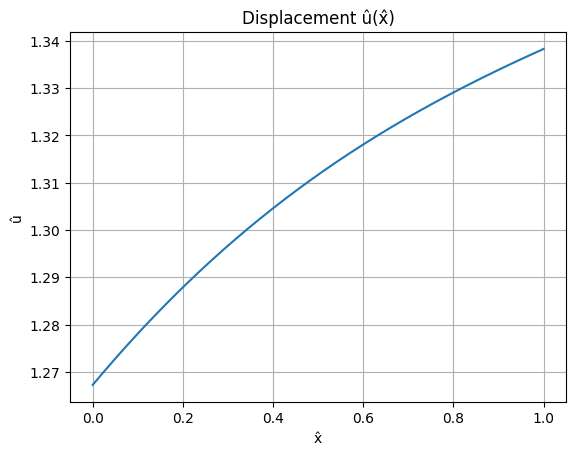

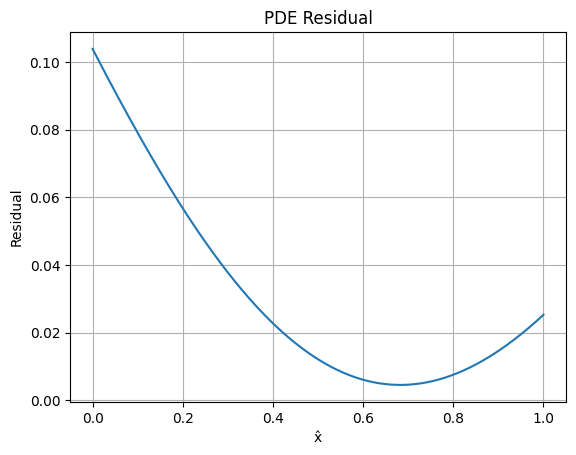

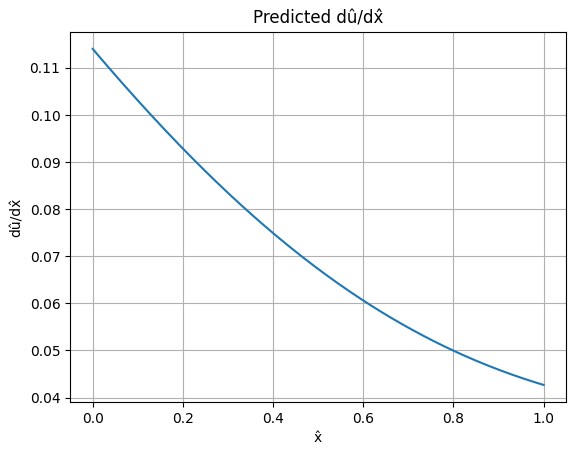

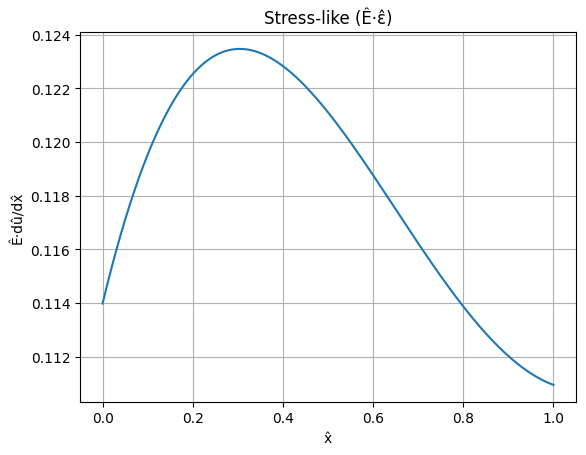

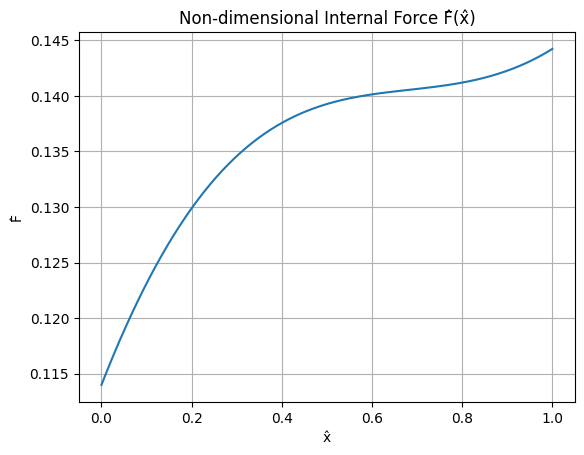

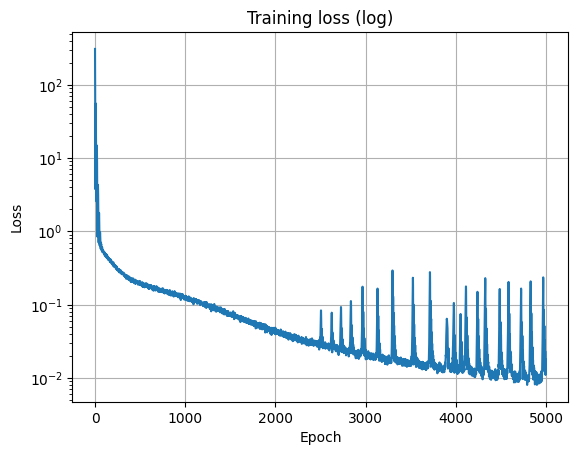

In [ ]:
# pinn_axial_bar_plots.py
# PyTorch PINN for 1D cantilever bar with variable E(x) and A(x)
# Includes tanh activation, Adam optimizer, PDE+BC losses, and plotting

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------- Physical ranges ----------------------
L = 1.0  # nondimensional length
E_min_GPa, E_max_GPa = 50.0, 210.0
E_ref_GPa = 50.0 # reference for nondim Ê
A0_mm2 = 100.0
A0 = A0_mm2 * 1e-6 # convert mm^2→m^2 (for clarity)
a_min, a_max = -0.8, 0.8
E_span_ratio = E_max_GPa / E_ref_GPa
b_min, b_max = 0.0, E_span_ratio - 1.0
T_hat = 1.0  # nondimensional tip traction

# ---------------------- Neural network ----------------------
class PINN(nn.Module):
 def __init__(self, layers):
   super().__init__()
   net = []
   for i in range(len(layers)-1):
     net.append(nn.Linear(layers[i], layers[i+1]))
     if i != len(layers)-2:
       net.append(nn.Tanh())
   self.net = nn.Sequential(*net)
   for m in self.net:
     if isinstance(m, nn.Linear):
       nn.init.xavier_normal_(m.weight)
       nn.init.zeros_(m.bias)

 def forward(self, x):
   return self.net(x)

# ---------------------- Helper functions ----------------------
def E_hat(xhat, b): return 1.0 + b * xhat
def A_hat(xhat, a): return 1.0 + a * xhat

# PDE residual: d/dx (ÊÂ du/dx) = 0
def pde_residual(model, xhat, params):
 xhat = xhat.clone().detach().requires_grad_(True)
 a = params[:, [0]]
 b = params[:, [1]]
 inp = torch.cat([xhat, params], dim=1)
 u = model(inp)
 du = torch.autograd.grad(u, xhat, torch.ones_like(u), create_graph=True)[0]
 flux = E_hat(xhat, b) * A_hat(xhat, a) * du
 dflux_dx = torch.autograd.grad(flux, xhat, torch.ones_like(flux), create_graph=True)[0]
 return dflux_dx, u, du

mse = nn.MSELoss()

def loss_pde(model, x, p):
 res, _, _ = pde_residual(model, x, p)
 return torch.mean(res**2)

def loss_bc(model, bc_dict):
 loss = torch.tensor(0.0, device=device)
 for x_val, params, u_val in bc_dict.get('dirichlet', []):
  x = torch.tensor([[x_val]], dtype=torch.float32, device=device)
  p = torch.tensor([params], dtype=torch.float32, device=device)
  u_pred = model(torch.cat([x,p], dim=1))
  loss += mse(u_pred, torch.tensor([[u_val]], dtype=torch.float32, device=device))
 for x_val, params, t_val in bc_dict.get('neumann', []):
  x = torch.tensor([[x_val]], dtype=torch.float32, requires_grad=True, device=device)
  p = torch.tensor([params], dtype=torch.float32, device=device)
  u_pred = model(torch.cat([x,p], dim=1))
  du = torch.autograd.grad(u_pred, x, torch.ones_like(u_pred), create_graph=True)[0]
  a = p[:, [0]]; b = p[:, [1]]
  # The traction is the non-dimensional force (ÊÂ du/dx), which should equal the tip traction T_hat
  traction = E_hat(x,b)*A_hat(x,a)*du
  loss += mse(traction, torch.tensor([[t_val]], dtype=torch.float32, device=device))
 return loss

# ---------------------- Training ----------------------
def train_pinn(model, epochs=5000, n_colloc=2000, w_pde=1.0, w_bc=200.0, print_every=300):
 opt = torch.optim.Adam(model.parameters(), lr=1e-3)
 mid_a, mid_b = 0.0, 0.5*(b_min+b_max)
 bc = {
  'dirichlet': [(0.0, (mid_a, mid_b), 0.0)], # fixed end
  'neumann':  [(1.0, (mid_a, mid_b), T_hat)] # traction at tip
 }
 hist = {'total': [], 'pde': [], 'bc': []}
 for ep in range(1, epochs+1):
  opt.zero_grad()
  x = torch.rand((n_colloc,1), dtype=torch.float32, device=device)
  a = torch.empty_like(x).uniform_(a_min,a_max)
  b = torch.empty_like(x).uniform_(b_min,b_max)
  p = torch.cat([a,b], dim=1)
  Lpde = loss_pde(model,x,p)
  Lbc = loss_bc(model,bc)
  loss = w_pde*Lpde + w_bc*Lbc
  loss.backward(); opt.step()
  hist['total'].append(loss.item())
  hist['pde'].append(Lpde.item())
  hist['bc'].append(Lbc.item())
  if ep%print_every==0 or ep==1:
   print(f"Epoch {ep:5d} | Loss={loss.item():.3e} | PDE={Lpde.item():.3e} | BC={Lbc.item():.3e}")
 return hist

# ---------------------- Main run ----------------------
if __name__ == "__main__":
 layers = [3,64,64,64,1]
 model = PINN(layers).to(device)
 hist = train_pinn(model)

 # Evaluate for a single (a,b)
 a_plot, b_plot = 0.3, 0.5*(b_min+b_max)
 x_plot = torch.linspace(0,1,300).unsqueeze(1).to(device)
 p_plot = torch.cat([torch.full_like(x_plot,a_plot), torch.full_like(x_plot,b_plot)], dim=1)
 res,u,du = pde_residual(model,x_plot,p_plot)
 res, u, du = res.detach().cpu().numpy(), u.detach().cpu().numpy(), du.detach().cpu().numpy()
 Ehat = E_hat(x_plot,b_plot).cpu().numpy()
 Ahat = A_hat(x_plot,a_plot).cpu().numpy() # << Added A_hat calculation
 stress_like = Ehat*du

 # <<< Internal Force Calculation >>>
 # Non-dimensional Force F_hat = A_hat * E_hat * du/dx_hat
 internal_force_hat = Ahat * stress_like

 # ---------------------- PLOTS ----------------------
 plt.figure(); plt.plot(x_plot.cpu(),u); plt.xlabel('x̂'); plt.ylabel('û'); plt.title('Displacement û(x̂)'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),res); plt.xlabel('x̂'); plt.ylabel('Residual'); plt.title('PDE Residual'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),du); plt.xlabel('x̂'); plt.ylabel('dû/dx̂'); plt.title('Predicted dû/dx̂'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),stress_like); plt.xlabel('x̂'); plt.ylabel('Ê·dû/dx̂'); plt.title('Stress-like (Ê·ε̂)'); plt.grid(True); plt.show()
 # <<< Internal Force Plot >>>
 plt.figure(); plt.plot(x_plot.cpu(),internal_force_hat); plt.xlabel('x̂'); plt.ylabel('F̂'); plt.title('Non-dimensional Internal Force F̂(x̂)'); plt.grid(True); plt.show()
 # <<< Loss Plot >>>
 plt.figure(); plt.semilogy(hist['total']); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training loss (log)'); plt.grid(True); plt.show()

L-BFGS AND ADAM OPTIMIZER

--- Starting ADAM Optimization ---
ADAM Epoch     1 | Loss=1.538e+02 | PDE=4.525e-02 | BC=7.688e-01
ADAM Epoch   300 | Loss=2.108e-01 | PDE=2.104e-01 | BC=2.040e-06
ADAM Epoch   600 | Loss=1.268e-01 | PDE=1.267e-01 | BC=6.247e-07
ADAM Epoch   900 | Loss=8.661e-02 | PDE=8.656e-02 | BC=2.625e-07
ADAM Epoch  1200 | Loss=5.662e-02 | PDE=5.657e-02 | BC=2.357e-07
ADAM Epoch  1500 | Loss=4.086e-02 | PDE=4.084e-02 | BC=6.415e-08
ADAM Epoch  1800 | Loss=3.358e-02 | PDE=3.328e-02 | BC=1.460e-06
ADAM Epoch  2100 | Loss=2.308e-01 | PDE=2.467e-02 | BC=1.030e-03
ADAM Epoch  2400 | Loss=4.446e-02 | PDE=2.215e-02 | BC=1.116e-04
ADAM Epoch  2700 | Loss=2.100e-02 | PDE=2.100e-02 | BC=9.828e-09
ADAM Epoch  3000 | Loss=8.089e-02 | PDE=1.830e-02 | BC=3.129e-04
ADAM Epoch  3300 | Loss=1.463e-02 | PDE=1.460e-02 | BC=1.762e-07
ADAM Epoch  3600 | Loss=1.493e-02 | PDE=1.446e-02 | BC=2.363e-06
ADAM Epoch  3900 | Loss=1.221e-02 | PDE=1.218e-02 | BC=1.623e-07
ADAM Epoch  4200 | Loss=1.129e-02 | PDE=1.114e-02 | BC=

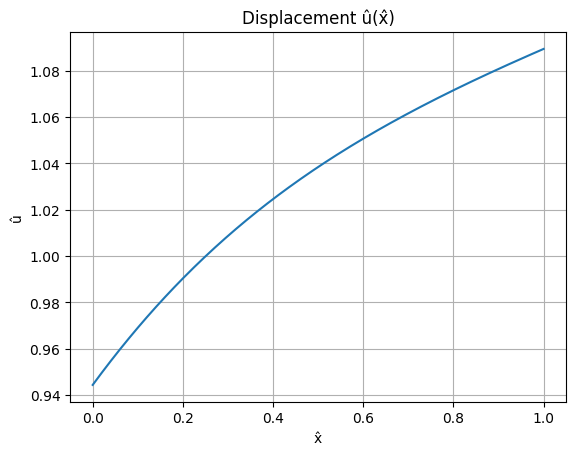

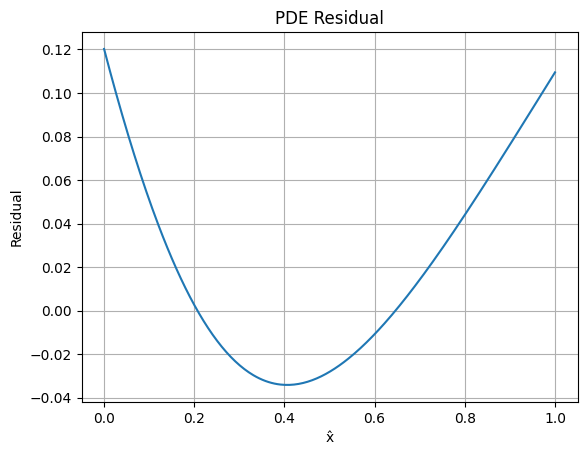

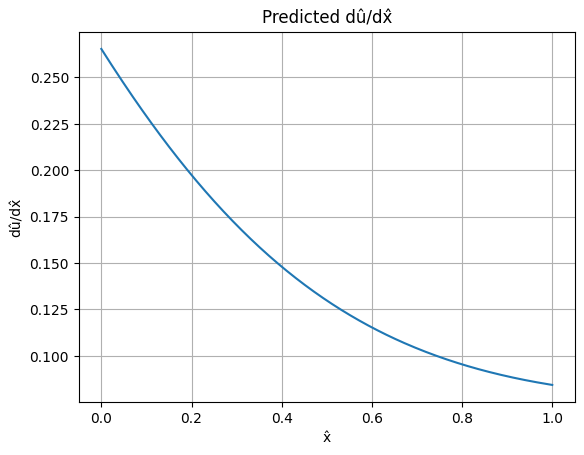

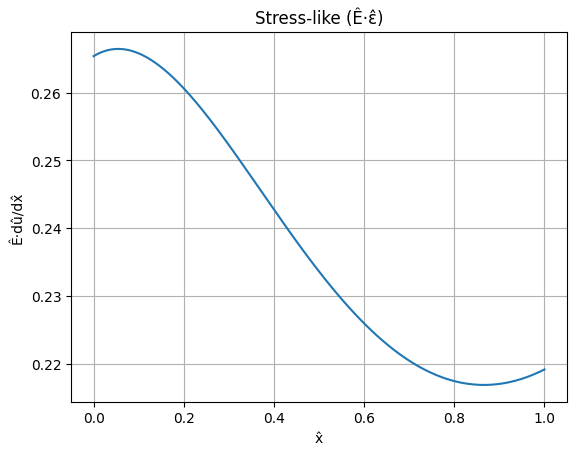

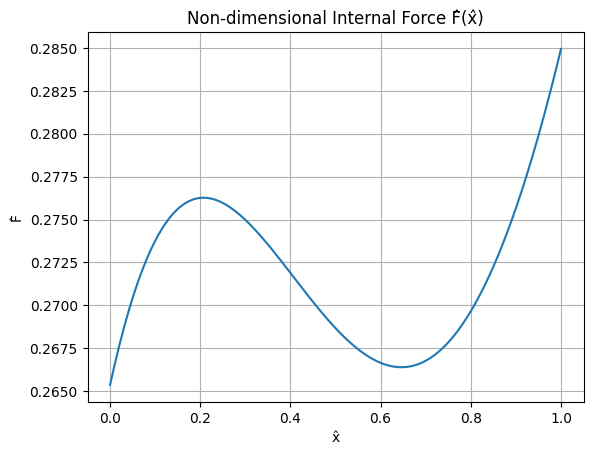

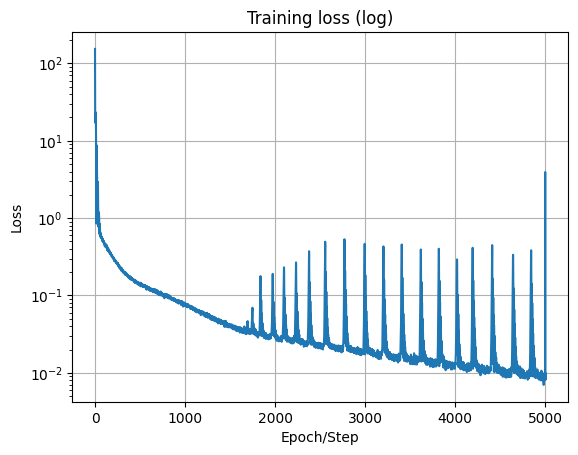

In [ ]:
# pinn_axial_bar_plots_lbfgs.py
# PyTorch PINN for 1D cantilever bar with variable E(x) and A(x)
# Includes tanh activation, Adam + L-BFGS optimizers, PDE+BC losses, and plotting

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------- Physical ranges ----------------------
L = 1.0# nondimensional length
E_min_GPa, E_max_GPa = 50.0, 210.0
E_ref_GPa = 50.0 # reference for nondim Ê
A0_mm2 = 100.0
A0 = A0_mm2 * 1e-6 # convert mm^2→m^2 (for clarity)
a_min, a_max = -0.8, 0.8
E_span_ratio = E_max_GPa / E_ref_GPa
b_min, b_max = 0.0, E_span_ratio - 1.0
T_hat = 1.0# nondimensional tip traction

# ---------------------- Neural network ----------------------
class PINN(nn.Module):
 def __init__(self, layers):
    super().__init__()
    net = []
    for i in range(len(layers)-1):
      net.append(nn.Linear(layers[i], layers[i+1]))
      if i != len(layers)-2:
        net.append(nn.Tanh())
    self.net = nn.Sequential(*net)
    for m in self.net:
      if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
 def forward(self, x):
  return self.net(x)

# ---------------------- Helper functions ----------------------
def E_hat(xhat, b): return 1.0 + b * xhat
def A_hat(xhat, a): return 1.0 + a * xhat

# PDE residual: d/dx (ÊÂ du/dx) = 0
def pde_residual(model, xhat, params):
 xhat = xhat.clone().detach().requires_grad_(True)
 a = params[:, [0]]
 b = params[:, [1]]
 inp = torch.cat([xhat, params], dim=1)
 u = model(inp)
 du = torch.autograd.grad(u, xhat, torch.ones_like(u), create_graph=True)[0]
 flux = E_hat(xhat, b) * A_hat(xhat, a) * du
 dflux_dx = torch.autograd.grad(flux, xhat, torch.ones_like(flux), create_graph=True)[0]
 return dflux_dx, u, du

mse = nn.MSELoss()

def loss_pde(model, x, p):
 res, _, _ = pde_residual(model, x, p)
 return torch.mean(res**2)

def loss_bc(model, bc_dict):
 loss = torch.tensor(0.0, device=device)
 for x_val, params, u_val in bc_dict.get('dirichlet', []):
     x = torch.tensor([[x_val]], dtype=torch.float32, device=device)
     p = torch.tensor([params], dtype=torch.float32, device=device)
     u_pred = model(torch.cat([x,p], dim=1))
     loss += mse(u_pred, torch.tensor([[u_val]], dtype=torch.float32, device=device))
 for x_val, params, t_val in bc_dict.get('neumann', []):
     x = torch.tensor([[x_val]], dtype=torch.float32, requires_grad=True, device=device)
     p = torch.tensor([params], dtype=torch.float32, device=device)
     u_pred = model(torch.cat([x,p], dim=1))
     du = torch.autograd.grad(u_pred, x, torch.ones_like(u_pred), create_graph=True)[0]
     a = p[:, [0]]; b = p[:, [1]]
     # The traction is the non-dimensional force (ÊÂ du/dx), which should equal the tip traction T_hat
     traction = E_hat(x,b)*A_hat(x,a)*du
     loss += mse(traction, torch.tensor([[t_val]], dtype=torch.float32, device=device))
 return loss

# ---------------------- Training ----------------------
def train_pinn(model, adam_epochs=5000, lbfgs_epochs=500, n_colloc=2000, w_pde=1.0, w_bc=200.0, print_every=300):
   mid_a, mid_b = 0.0, 0.5*(b_min+b_max)
   bc = {
      'dirichlet': [(0.0, (mid_a, mid_b), 0.0)],# fixed end
      'neumann':[(1.0, (mid_a, mid_b), T_hat)] # traction at tip
   }
   hist = {'total': [], 'pde': [], 'bc': []}

   # --- ADAM Phase ---
   print("--- Starting ADAM Optimization ---")
   opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

   for ep in range(1, adam_epochs + 1):
     opt_adam.zero_grad()
     x = torch.rand((n_colloc,1), dtype=torch.float32, device=device)
     a = torch.empty_like(x).uniform_(a_min,a_max)
     b = torch.empty_like(x).uniform_(b_min,b_max)
     p = torch.cat([a,b], dim=1)
     Lpde = loss_pde(model,x,p)
     Lbc = loss_bc(model,bc)
     loss = w_pde*Lpde + w_bc*Lbc
     loss.backward(); opt_adam.step()
     hist['total'].append(loss.item())
     hist['pde'].append(Lpde.item())
     hist['bc'].append(Lbc.item())
     if ep % print_every == 0 or ep == 1:
         print(f"ADAM Epoch {ep:5d} | Loss={loss.item():.3e} | PDE={Lpde.item():.3e} | BC={Lbc.item():.3e}")
     # --- L-BFGS Phase (for refinement) ---
   print("\n--- Starting L-BFGS Optimization ---")
   opt_lbfgs = torch.optim.LBFGS(
      model.parameters(),
      lr=1.0, # Initial large LR for LBFGS
      max_iter=lbfgs_epochs,
      tolerance_grad=1e-7,
      tolerance_change=1e-9,
      line_search_fn="strong_wolfe"
    )
   def closure():
     opt_lbfgs.zero_grad()
     # Note: L-BFGS reuses the same set of collocation points per major step
     x_lbfgs = torch.rand((n_colloc,1), dtype=torch.float32, device=device)
     a_lbfgs = torch.empty_like(x_lbfgs).uniform_(a_min,a_max)
     b_lbfgs = torch.empty_like(x_lbfgs).uniform_(b_min,b_max)
     p_lbfgs = torch.cat([a_lbfgs,b_lbfgs], dim=1)
     Lpde = loss_pde(model, x_lbfgs, p_lbfgs)
     Lbc = loss_bc(model, bc)
     loss = w_pde*Lpde + w_bc*Lbc

     if loss.requires_grad:
         loss.backward()

     hist['total'].append(loss.item())
     hist['pde'].append(Lpde.item())
     hist['bc'].append(Lbc.item())
     # L-BFGS prints loss on every internal iteration, so we print on the major step
     if len(hist['total']) % print_every == 0:
         print(f"LBFGS Step {len(hist['total']):5d} | Loss={loss.item():.3e} | PDE={Lpde.item():.3e} | BC={Lbc.item():.3e}")
     return loss
 # Run the L-BFGS optimizer. It calls 'closure' multiple times internally.
   opt_lbfgs.step(closure)

   print("--- Optimization Complete ---")
   return hist
#--------------------- Main run ----------------------
if __name__ == "__main__":
 layers = [3,64,64,64,1]
 model = PINN(layers).to(device)
 # Changed call to include both sets of epochs
 hist = train_pinn(model, adam_epochs=5000, lbfgs_epochs=1000)
 # Evaluate for a single (a,b)
 a_plot, b_plot = 0.3, 0.5*(b_min+b_max)
 x_plot = torch.linspace(0,1,300).unsqueeze(1).to(device)
 p_plot = torch.cat([torch.full_like(x_plot,a_plot), torch.full_like(x_plot,b_plot)], dim=1)
 res,u,du = pde_residual(model,x_plot,p_plot)
 res, u, du = res.detach().cpu().numpy(), u.detach().cpu().numpy(), du.detach().cpu().numpy()
 Ehat = E_hat(x_plot,b_plot).cpu().numpy()
 Ahat = A_hat(x_plot,a_plot).cpu().numpy()
 stress_like = Ehat*du
 internal_force_hat = Ahat * stress_like

 # ---------------------- PLOTS ----------------------
 plt.figure(); plt.plot(x_plot.cpu(),u); plt.xlabel('x̂'); plt.ylabel('û'); plt.title('Displacement û(x̂)'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),res); plt.xlabel('x̂'); plt.ylabel('Residual'); plt.title('PDE Residual'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),du); plt.xlabel('x̂'); plt.ylabel('dû/dx̂'); plt.title('Predicted dû/dx̂'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),stress_like); plt.xlabel('x̂'); plt.ylabel('Ê·dû/dx̂'); plt.title('Stress-like (Ê·ε̂)'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),internal_force_hat); plt.xlabel('x̂'); plt.ylabel('F̂'); plt.title('Non-dimensional Internal Force F̂(x̂)'); plt.grid(True); plt.show()
 plt.figure(); plt.semilogy(hist['total']); plt.xlabel('Epoch/Step'); plt.ylabel('Loss'); plt.title('Training loss (log)'); plt.grid(True); plt.show()

--- Starting ADAM Optimization ---

--- Starting L-BFGS Optimization ---
--- Optimization Complete ---


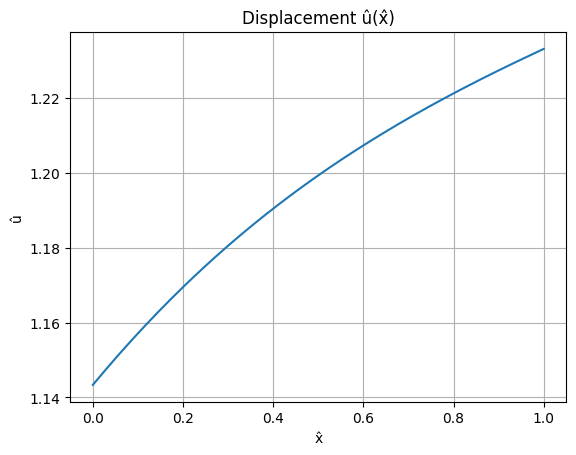

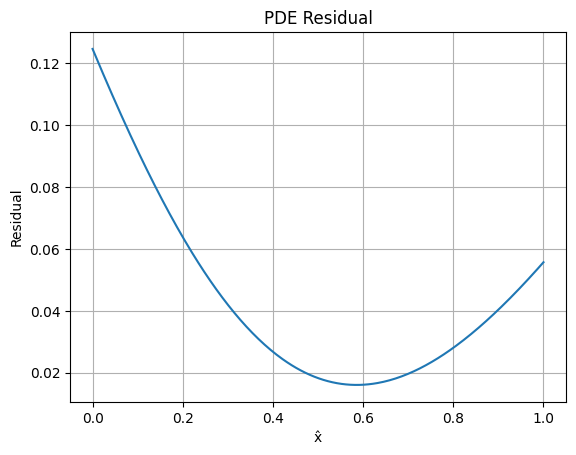

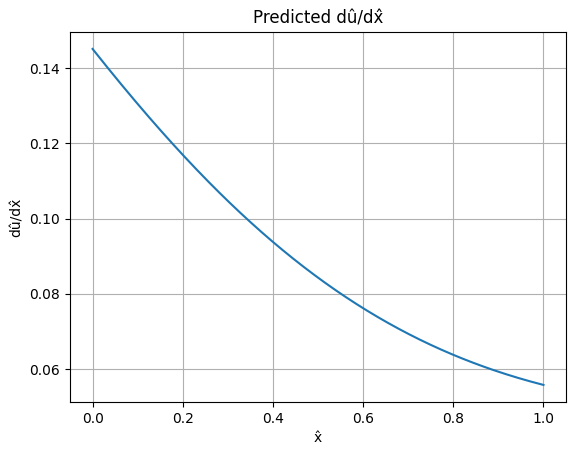

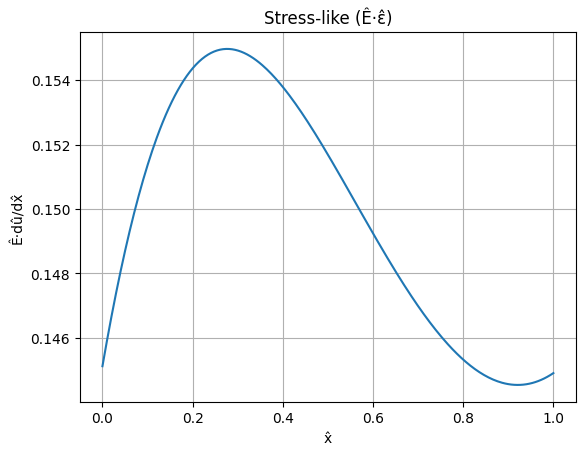

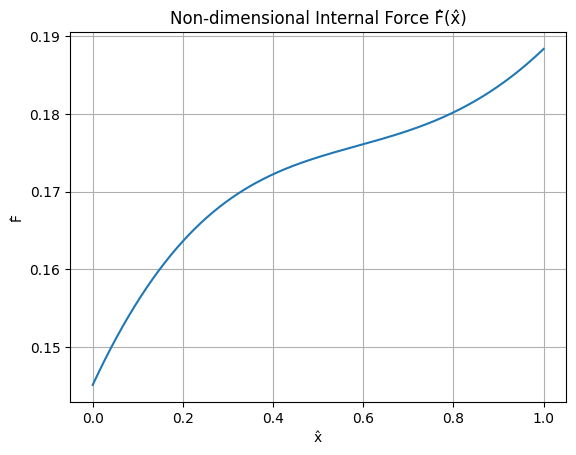

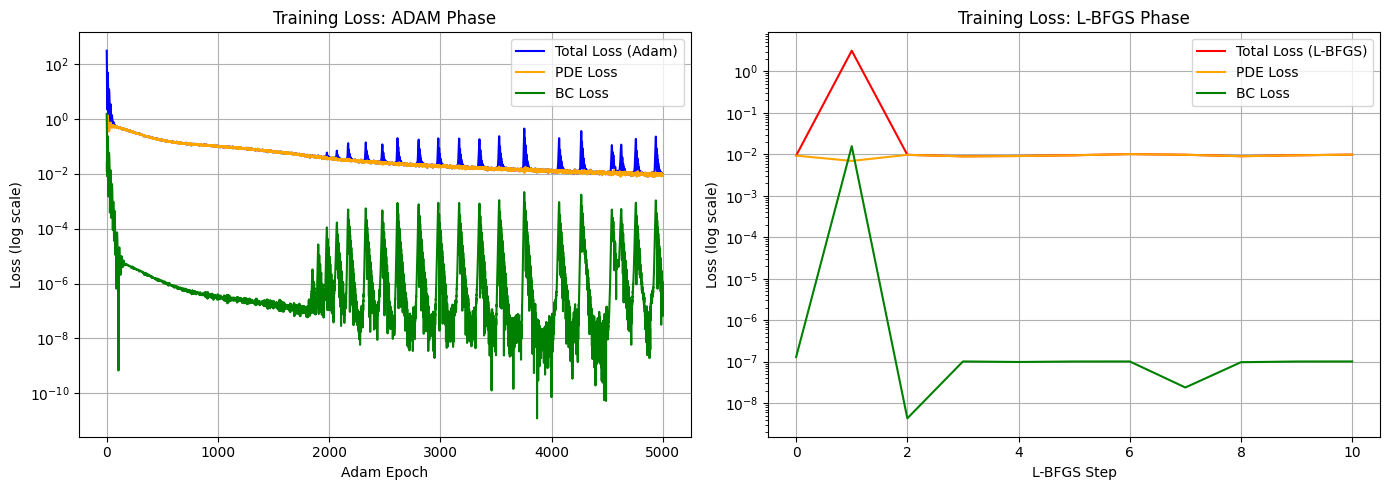

In [ ]:
# pinn_axial_bar_plots_lbfgs.py
# PyTorch PINN for 1D cantilever bar with variable E(x) and A(x)
# Includes tanh activation, Adam + L-BFGS optimizers, PDE+BC losses, and plotting

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------- Physical ranges ----------------------
L = 1.0# nondimensional length
E_min_GPa, E_max_GPa = 50.0, 210.0
E_ref_GPa = 50.0 # reference for nondim Ê
A0_mm2 = 100.0
A0 = A0_mm2 * 1e-6 # convert mm^2→m^2 (for clarity)
a_min, a_max = -0.8, 0.8
E_span_ratio = E_max_GPa / E_ref_GPa
b_min, b_max = 0.0, E_span_ratio - 1.0
T_hat = 1.0# nondimensional tip traction

# ---------------------- Neural network ----------------------
class PINN(nn.Module):
   def __init__(self, layers):
       super().__init__()
       net = []
       for i in range(len(layers)-1):
          net.append(nn.Linear(layers[i], layers[i+1]))
          if i != len(layers)-2:
             net.append(nn.Tanh())
       self.net = nn.Sequential(*net)
       for m in self.net:
             if isinstance(m, nn.Linear):
                 nn.init.xavier_normal_(m.weight)
                 nn.init.zeros_(m.bias)
   def forward(self, x):
     return self.net(x)

# ---------------------- Helper functions ----------------------
def E_hat(xhat, b): return 1.0 + b * xhat
def A_hat(xhat, a): return 1.0 + a * xhat

# PDE residual: d/dx (ÊÂ du/dx) = 0
def pde_residual(model, xhat, params):
      xhat = xhat.clone().detach().requires_grad_(True)
      a = params[:, [0]]
      b = params[:, [1]]
      inp = torch.cat([xhat, params], dim=1)
      u = model(inp)
      du = torch.autograd.grad(u, xhat, torch.ones_like(u), create_graph=True)[0]
      flux = E_hat(xhat, b) * A_hat(xhat, a) * du
      dflux_dx = torch.autograd.grad(flux, xhat, torch.ones_like(flux), create_graph=True)[0]
      return dflux_dx, u, du

mse = nn.MSELoss()

def loss_pde(model, x, p):
     res, _, _ = pde_residual(model, x, p)
     return torch.mean(res**2)

def loss_bc(model, bc_dict):
     loss = torch.tensor(0.0, device=device)
     for x_val, params, u_val in bc_dict.get('dirichlet', []):
          x = torch.tensor([[x_val]], dtype=torch.float32, device=device)
          p = torch.tensor([params], dtype=torch.float32, device=device)
          u_pred = model(torch.cat([x,p], dim=1))
          loss += mse(u_pred, torch.tensor([[u_val]], dtype=torch.float32, device=device))
     for x_val, params, t_val in bc_dict.get('neumann', []):
          x = torch.tensor([[x_val]], dtype=torch.float32, requires_grad=True, device=device)
          p = torch.tensor([params], dtype=torch.float32, device=device)
          u_pred = model(torch.cat([x,p], dim=1))
          du = torch.autograd.grad(u_pred, x, torch.ones_like(u_pred), create_graph=True)[0]
          a = p[:, [0]]; b = p[:, [1]]
          # The traction is the non-dimensional force (ÊÂ du/dx), which should equal the tip traction T_hat
          traction = E_hat(x,b)*A_hat(x,a)*du
          loss += mse(traction, torch.tensor([[t_val]], dtype=torch.float32, device=device))
     return loss

# ---------------------- Training ----------------------
def train_pinn(model, adam_epochs=5000, lbfgs_epochs=500, n_colloc=2000, w_pde=1.0, w_bc=200.0, print_every=300):
     mid_a, mid_b = 0.0, 0.5*(b_min+b_max)
     bc = {
      'dirichlet': [(0.0, (mid_a, mid_b), 0.0)], # fixed end
      'neumann':[(1.0, (mid_a, mid_b), T_hat)] # traction at tip
     }

    # MODIFIED: Use separate lists for Adam and L-BFGS
     hist_adam = {'total': [], 'pde': [], 'bc': []}
     hist_lbfgs = {'total': [], 'pde': [], 'bc': []}

     # --- ADAM Phase ---
     print("--- Starting ADAM Optimization ---")
     opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

     for ep in range(1, adam_epochs + 1):
        opt_adam.zero_grad()
        x = torch.rand((n_colloc,1), dtype=torch.float32, device=device)
        a = torch.empty_like(x).uniform_(a_min,a_max)
        b = torch.empty_like(x).uniform_(b_min,b_max)
        p = torch.cat([a,b], dim=1)
        Lpde = loss_pde(model,x,p)
        Lbc = loss_bc(model,bc)
        loss = w_pde*Lpde + w_bc*Lbc
        loss.backward(); opt_adam.step()

        # MODIFIED: Append to Adam history
        hist_adam['total'].append(loss.item())
        hist_adam['pde'].append(Lpde.item())
        hist_adam['bc'].append(Lbc.item())

     if ep % print_every == 0 or ep == 1:
          print(f"ADAM Epoch {ep:5d} | Loss={loss.item():.3e} | PDE={Lpde.item():.3e} | BC={Lbc.item():.3e}")

 # --- L-BFGS Phase (for refinement) ---
     print("\n--- Starting L-BFGS Optimization ---")
     opt_lbfgs = torch.optim.LBFGS(
          model.parameters(),
          lr=1.0,
          max_iter=lbfgs_epochs,
          tolerance_grad=1e-7,
          tolerance_change=1e-9,
          line_search_fn="strong_wolfe"
        )

     def closure():
         opt_lbfgs.zero_grad()
         x_lbfgs = torch.rand((n_colloc,1), dtype=torch.float32, device=device)
         a_lbfgs = torch.empty_like(x_lbfgs).uniform_(a_min,a_max)
         b_lbfgs = torch.empty_like(x_lbfgs).uniform_(b_min,b_max)
         p_lbfgs = torch.cat([a_lbfgs,b_lbfgs], dim=1)
         Lpde = loss_pde(model, x_lbfgs, p_lbfgs)
         Lbc = loss_bc(model, bc)
         loss = w_pde*Lpde + w_bc*Lbc

         if loss.requires_grad:
             loss.backward()

        # MODIFIED: Append to L-BFGS history
         hist_lbfgs['total'].append(loss.item())
         hist_lbfgs['pde'].append(Lpde.item())
         hist_lbfgs['bc'].append(Lbc.item())

         # L-BFGS prints loss on every internal iteration
         if len(hist_lbfgs['total']) % print_every == 0:
              print(f"LBFGS Step {len(hist_lbfgs['total']):5d} | Loss={loss.item():.3e} | PDE={Lpde.item():.3e} | BC={Lbc.item():.3e}")
         return loss

     # Run the L-BFGS optimizer.
     opt_lbfgs.step(closure)

     print("--- Optimization Complete ---")
     # MODIFIED: Return the separate histories
     return hist_adam, hist_lbfgs

# ---------------------- Main run ----------------------
if __name__ == "__main__":
 layers = [3,64,64,64,1]
 model = PINN(layers).to(device)
    # MODIFIED: Receive two return values
 hist_adam, hist_lbfgs = train_pinn(model, adam_epochs=5000, lbfgs_epochs=1000)

 # Evaluate for a single (a,b)
 a_plot, b_plot = 0.3, 0.5*(b_min+b_max)
 x_plot = torch.linspace(0,1,300).unsqueeze(1).to(device)
 p_plot = torch.cat([torch.full_like(x_plot,a_plot), torch.full_like(x_plot,b_plot)], dim=1)
 res,u,du = pde_residual(model,x_plot,p_plot)
 res, u, du = res.detach().cpu().numpy(), u.detach().cpu().numpy(), du.detach().cpu().numpy()
 Ehat = E_hat(x_plot,b_plot).cpu().numpy()
 Ahat = A_hat(x_plot,a_plot).cpu().numpy()
 stress_like = Ehat*du
 internal_force_hat = Ahat * stress_like

 # ---------------------- PLOTS ----------------------
 # Note: I'm keeping the original plots for completeness, but focusing on the new loss plot below.
 plt.figure(); plt.plot(x_plot.cpu(),u); plt.xlabel('x̂'); plt.ylabel('û'); plt.title('Displacement û(x̂)'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),res); plt.xlabel('x̂'); plt.ylabel('Residual'); plt.title('PDE Residual'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),du); plt.xlabel('x̂'); plt.ylabel('dû/dx̂'); plt.title('Predicted dû/dx̂'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),stress_like); plt.xlabel('x̂'); plt.ylabel('Ê·dû/dx̂'); plt.title('Stress-like (Ê·ε̂)'); plt.grid(True); plt.show()
 plt.figure(); plt.plot(x_plot.cpu(),internal_force_hat); plt.xlabel('x̂'); plt.ylabel('F̂'); plt.title('Non-dimensional Internal Force F̂(x̂)'); plt.grid(True); plt.show()

    # <<< MODIFIED LOSS PLOT >>>
 fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Adam Plot
 axes[0].semilogy(hist_adam['total'], label='Total Loss (Adam)', color='blue')
 axes[0].semilogy(hist_adam['pde'], label='PDE Loss', color='orange')
 axes[0].semilogy(hist_adam['bc'], label='BC Loss', color='green')
 axes[0].set_xlabel('Adam Epoch')
 axes[0].set_ylabel('Loss (log scale)')
 axes[0].set_title('Training Loss: ADAM Phase')
 axes[0].grid(True)
 axes[0].legend()

    # L-BFGS Plot
    # Note: L-BFGS performs multiple steps per major iteration, so this plot shows all steps.
 axes[1].semilogy(hist_lbfgs['total'], label='Total Loss (L-BFGS)', color='red')
 axes[1].semilogy(hist_lbfgs['pde'], label='PDE Loss', color='orange')
 axes[1].semilogy(hist_lbfgs['bc'], label='BC Loss', color='green')
 axes[1].set_xlabel('L-BFGS Step')
 axes[1].set_ylabel('Loss (log scale)')
 axes[1].set_title('Training Loss: L-BFGS Phase')
 axes[1].grid(True)
 axes[1].legend()
 plt.tight_layout()
 plt.show()